正在讀取資料...
資料清理完成！共保留 13062 筆有效資料。

正在執行複迴歸分析...
                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     2356.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:14:42   Log-Likelihood:                -53522.
No. Observations:               13062   AIC:                         1.070e+05
Df Residuals:                   13059   BIC:                         1.071e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

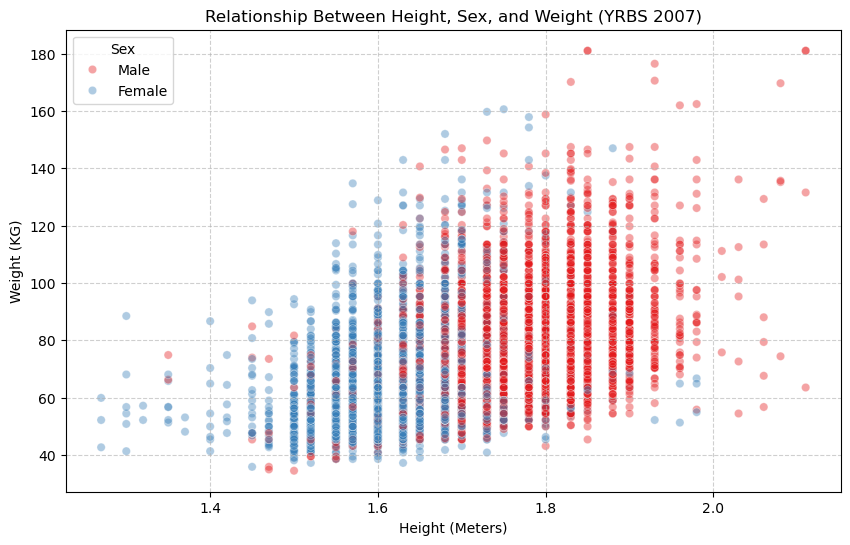


正在繪製圖表二：男女體重分佈箱形圖...
圖表二已成功儲存至：../output/weight_distribution_by_sex.png


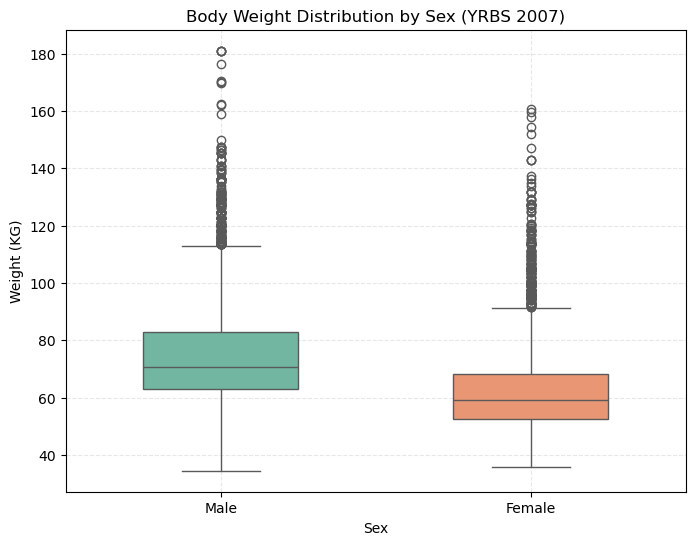

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# 1. 讀取資料
print("正在讀取資料...")
df = pd.read_csv('../data/YRBS_2007.csv')

# 2. 資料清理 (Data Cleaning)
cols_to_keep = ['WhatIsYourSex', 'HowTallAreYouWithoutShoesInMeters', 'HowMuchDoYouWeighWithoutShoesInKG']
df_clean = df[cols_to_keep].dropna().copy()
df_clean.columns = ['Sex', 'Height', 'Weight']

# 【關鍵修正 1】：先轉為浮點數再對應，避免 1.0 與 '1' 的格式衝突
df_clean['Sex'] = df_clean['Sex'].astype(float).map({1.0: 'Female', 2.0: 'Male'})
# 再次清理確保沒有轉換失敗的空值
df_clean = df_clean.dropna()

print(f"資料清理完成！共保留 {len(df_clean)} 筆有效資料。\n")

# 3. 建立複迴歸模型 (Multiple Linear Regression)
print("正在執行複迴歸分析...")
model = smf.ols('Weight ~ Height + C(Sex)', data=df_clean).fit()
print(model.summary())

# ==========================================
# 4. 圖表一：身高與體重的迴歸散佈圖
# ==========================================
print("\n正在繪製圖表一：迴歸散佈圖...")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Height', y='Weight', hue='Sex', alpha=0.4, palette='Set1')

plt.title('Relationship Between Height, Sex, and Weight (YRBS 2007)')
plt.xlabel('Height (Meters)')
plt.ylabel('Weight (KG)')
plt.legend(title='Sex')
plt.grid(True, linestyle='--', alpha=0.6)

# 【關鍵修正 2】：移除 bbox_inches='tight'，避免儲存時邊界計算錯誤
output_path1 = '../output/height_weight_regression.png'
plt.savefig(output_path1, dpi=300)
print(f"圖表一已儲存至：{output_path1}")
plt.show()

# ==========================================
# 5. 圖表二：男女體重分佈箱形圖
# ==========================================
print("\n正在繪製圖表二：男女體重分佈箱形圖...")
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Sex', y='Weight', hue='Sex', palette='Set2', width=0.5, legend=False)

plt.title('Body Weight Distribution by Sex (YRBS 2007)')
plt.xlabel('Sex')
plt.ylabel('Weight (KG)')
plt.grid(True, linestyle='--', alpha=0.3)

# 【關鍵修正 2】：移除 bbox_inches='tight'
output_path2 = '../output/weight_distribution_by_sex.png'
plt.savefig(output_path2, dpi=300)
print(f"圖表二已成功儲存至：{output_path2}")
plt.show()